In [158]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Подготовка данных

In [159]:
class GlobalMaxPool1D(nn.Module):
    def forward(self, x):          # x: (B, T, C)
        return x.max(dim=1).values # (B, C)

In [160]:
df = pd.read_csv('/content/tech_support_topics.csv')
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [161]:
df['Topic_group'].value_counts()

,count
Topic_group,
Hardware,13617
HR Support,10915
Access,7125
Miscellaneous,7060
Storage,2777
Purchase,2464
Internal Project,2119
Administrative rights,1760


In [162]:
df_encoded = pd.get_dummies(df, columns=['Topic_group'], prefix='Topic_group', dtype=int)
encoded_cols = [col for col in df_encoded.columns if col.startswith('Topic_group_')]
labels = df_encoded[encoded_cols]
labels.head()

,Topic_group_Access,Topic_group_Administrative rights,Topic_group_HR Support,Topic_group_Hardware,Topic_group_Internal Project,Topic_group_Miscellaneous,Topic_group_Purchase,Topic_group_Storage
0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0


In [163]:
labels.shape

(47837, 8)

In [164]:
from collections import Counter
counter = Counter(" ".join(df['Document'].values).split())
print(counter)
print(len(counter.keys()))

Counter({'please': 70212, 'pm': 28902, 'hi': 28498, 'regards': 27212, 'thank': 24962, 'for': 24456, 'hello': 23025, 'you': 21828, 're': 21034, 'thanks': 19852, 'sent': 14717, 'kind': 13241, 'access': 13153, 'help': 11173, 'tuesday': 10896, 'with': 10555, 'wednesday': 10428, 'dear': 10320, 'thursday': 9935, 'can': 9526, 'have': 9476, 'friday': 9441, 'by': 9418, 'best': 9390, 'error': 9291, 'issue': 8802, 'july': 8790, 'to': 8424, 'change': 7816, 'has': 7691, 'be': 7652, 'engineer': 7545, 'log': 7280, 'ext': 7235, 'add': 7231, 'let': 6606, 'date': 6558, 'information': 6500, 'attached': 6452, 'october': 6430, 'form': 6303, 'we': 6281, 'new': 6271, 'senior': 6207, 'november': 6146, 'also': 6136, 'details': 6129, 'leaver': 6096, 'name': 6005, 'your': 5631, 'code': 5629, 'update': 5601, 'order': 5433, 'issues': 5374, 'analyst': 5305, 'leave': 5288, 'report': 5149, 'card': 5115, 'december': 5068, 'site': 5053, 'number': 4946, 'create': 4903, 'client': 4871, 'starter': 4816, 'could': 4816, 'co

In [165]:
n_most_common_words = 1000
max_len = 100

# Инициализация и обучение токенизатора
tokenizer = Tokenizer(num_words=n_most_common_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(df['Document'].values)
sequences = tokenizer.texts_to_sequences(df['Document'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

# Пэддинг до фиксированной длины max_len
X = pad_sequences(sequences, maxlen=max_len)

Found 12326 unique tokens.


In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.1, random_state=42, stratify=labels)
X_train, X_test, y_train, y_test = np.asarray(X_train), np.asarray(X_test), np.asarray(y_train), np.asarray(y_test)

In [167]:
EMBEDDING_DIM = 64
EPOCHS = 1000
BATCH_SIZE = 128

In [168]:
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

dataloader_train = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
dataloader_test = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

# LSTM

In [169]:
class LSTMRNN(nn.Module):
    def __init__(self):
        super(LSTMRNN, self).__init__()
        self.embd = nn.Embedding(n_most_common_words, EMBEDDING_DIM)
        self.lstm = nn.LSTM(input_size=EMBEDDING_DIM, hidden_size=128, batch_first=True, num_layers=2, dropout=0.2)
        self.globalpool = GlobalMaxPool1D()
        self.dense1 = nn.Linear(128, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.dense2 = nn.Linear(128, 8)

    def forward(self, x):
        x = self.embd(x)
        x, _ = self.lstm(x)
        x = self.globalpool(x)
        x = self.relu(self.dense1(x))
        x = self.dropout(x)
        out = self.dense2(x)
        return out

In [170]:
model = LSTMRNN()

In [171]:
criterion = nn.CrossEntropyLoss()

In [172]:
LEARNING_RATE_PT = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_PT)

In [173]:
# Функция для проведения одной эпохи обучения
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()   # переводим модель в режим обучения, включая dropout и batchnorm слои
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for writes, labels in progress_bar:  # перебор обучающей выборки на одной эпохе
        writes, labels = writes.to(device), labels.to(device)

        optimizer.zero_grad()   # обнуление градиентов, которые остались с предыдущего шага
        outputs = model(writes) # пропускаем данные батча через модель
        loss = criterion(outputs, labels.float())   # вычисляем функцию потерь
        loss.backward() # обратное распространение ошибки
        optimizer.step()    # делаем шаг оптимизатора

        total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
        correct += (predicted == labels.float()).all(1).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    # Подсчет метрик и функции потерь на тестовой выборке после окончания эпохи
    model.eval() # переводим модель в режим инференса
    with torch.no_grad():
        for writes, labels in test_data_loader:
            writes, labels = writes.to(device), labels.to(device)

            outputs = model(writes)
            loss = criterion(outputs, labels.float())

            test_total_loss += loss.item()
            # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
            predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
            test_correct += (predicted == labels.float()).all(1).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [174]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cuda


LSTMRNN(
  (embd): Embedding(1000, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (globalpool): GlobalMaxPool1D()
  (dense1): Linear(in_features=128, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (dense2): Linear(in_features=128, out_features=8, bias=True)
)

In [175]:
patience = 10

best_val_loss = float("inf")
best_epoch = 0
best_state_dict = None
epochs_no_improve = 0

EPOCHS_PT = 1000
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(EPOCHS_PT):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{EPOCHS_PT}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_epoch = epoch+1
        best_state_dict = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Epoch {epoch+1}: early stopping")
            if best_state_dict is not None:
                model.load_state_dict(best_state_dict)
                print(f"Restoring model weights from the end of the best epoch: {best_epoch}")
            break


Epoch 1/1000, Loss: 1.5661, Accuracy: 0.1833, Test Loss: 1.0654, Test Accuracy: 0.4457



Epoch 2/1000, Loss: 0.7559, Accuracy: 0.6615, Test Loss: 0.5414, Test Accuracy: 0.7926



Epoch 3/1000, Loss: 0.5083, Accuracy: 0.7937, Test Loss: 0.4732, Test Accuracy: 0.8096



Epoch 4/1000, Loss: 0.4361, Accuracy: 0.8259, Test Loss: 0.4644, Test Accuracy: 0.8248



Epoch 5/1000, Loss: 0.3881, Accuracy: 0.8476, Test Loss: 0.4483, Test Accuracy: 0.8330


...


Epoch 12/1000, Loss: 0.1855, Accuracy: 0.9321, Test Loss: 0.5436, Test Accuracy: 0.8395



Epoch 13/1000, Loss: 0.1640, Accuracy: 0.9388, Test Loss: 0.5911, Test Accuracy: 0.8407



Epoch 14/1000, Loss: 0.1482, Accuracy: 0.9458, Test Loss: 0.5852, Test Accuracy: 0.8466



Epoch 15/1000, Loss: 0.1306, Accuracy: 0.9534, Test Loss: 0.6036, Test Accuracy: 0.8424



Epoch 16/1000, Loss: 0.1123, Accuracy: 0.9597, Test Loss: 0.6549, Test Accuracy: 0.8407
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6


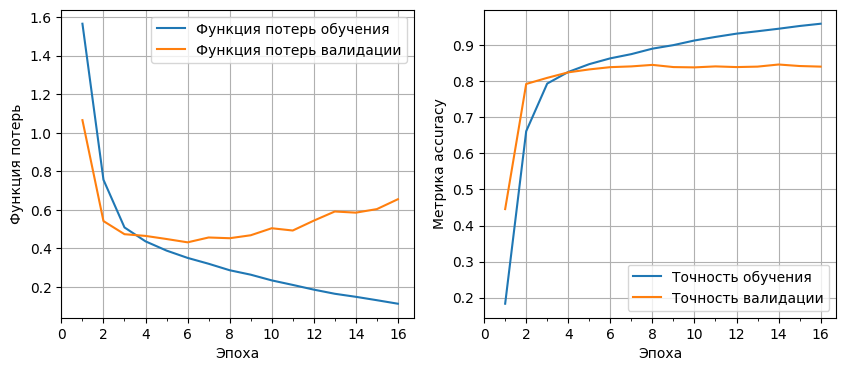

In [176]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
EPOCHS = len(history['loss'])
axs[0].plot(np.arange(1, EPOCHS + 1), history['loss'], label='Функция потерь обучения')
axs[0].plot(np.arange(1, EPOCHS + 1), history['val_loss'], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, EPOCHS + 1, 2))
axs[0].set_xticks(np.arange(0, EPOCHS + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, EPOCHS + 1), history['accuracy'], label='Точность обучения')
axs[1].plot(np.arange(1, EPOCHS + 1), history['val_accuracy'], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, EPOCHS + 1, 2))
axs[1].set_xticks(np.arange(0, EPOCHS + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

In [177]:
test_total_loss, test_correct = 0, 0

model.eval() # переводим модель в режим инференса
with torch.no_grad():
    for writes, labels in dataloader_test:
        writes, labels = writes.to(device), labels.to(device)

        outputs = model(writes)
        loss = criterion(outputs, labels.float())

        test_total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
        test_correct += (predicted == labels.float()).all(1).sum().item()

test_loss = test_total_loss / len(dataloader_test)
test_accuracy = test_correct / len(dataloader_test.dataset)
print('Ошибка:', test_loss)
print('Точность:', test_accuracy)

Ошибка: 0.431031733751297
Точность: 0.8392558528428093


# Biderectional LSTM

In [186]:
class BiLSTMRNN(nn.Module):
    def __init__(self):
        super(BiLSTMRNN, self).__init__()
        self.embd = nn.Embedding(n_most_common_words, EMBEDDING_DIM)
        self.lstm = nn.LSTM(input_size=EMBEDDING_DIM, hidden_size=128, batch_first=True, num_layers=2, dropout=0.2, bidirectional=True)
        self.globalpool = GlobalMaxPool1D()
        self.dense1 = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.dense2 = nn.Linear(128, 8)

    def forward(self, x):
        x = self.embd(x)
        x, _ = self.lstm(x)
        x = self.globalpool(x)
        x = self.relu(self.dense1(x))
        x = self.dropout1(x)
        out = self.dense2(x)
        return out

In [187]:
model = BiLSTMRNN()

In [188]:
criterion = nn.CrossEntropyLoss()

In [189]:
LEARNING_RATE_PT = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_PT)

In [190]:
# Функция для проведения одной эпохи обучения
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()   # переводим модель в режим обучения, включая dropout и batchnorm слои
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for writes, labels in progress_bar:  # перебор обучающей выборки на одной эпохе
        writes, labels = writes.to(device), labels.to(device)

        optimizer.zero_grad()   # обнуление градиентов, которые остались с предыдущего шага
        outputs = model(writes) # пропускаем данные батча через модель
        loss = criterion(outputs, labels.float())   # вычисляем функцию потерь
        loss.backward() # обратное распространение ошибки
        optimizer.step()    # делаем шаг оптимизатора

        total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
        correct += (predicted == labels.float()).all(1).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    # Подсчет метрик и функции потерь на тестовой выборке после окончания эпохи
    model.eval() # переводим модель в режим инференса
    with torch.no_grad():
        for writes, labels in test_data_loader:
            writes, labels = writes.to(device), labels.to(device)

            outputs = model(writes)
            loss = criterion(outputs, labels.float())

            test_total_loss += loss.item()
            # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
            predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
            test_correct += (predicted == labels.float()).all(1).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [191]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cuda


BiLSTMRNN(
  (embd): Embedding(1000, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (globalpool): GlobalMaxPool1D()
  (dense1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (dense2): Linear(in_features=128, out_features=8, bias=True)
)

In [192]:
patience = 10

best_val_loss = float("inf")
best_epoch = 0
best_state_dict = None
epochs_no_improve = 0

EPOCHS_PT = 1000
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(EPOCHS_PT):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{EPOCHS_PT}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_epoch = epoch+1
        best_state_dict = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Epoch {epoch+1}: early stopping")
            if best_state_dict is not None:
                model.load_state_dict(best_state_dict)
                print(f"Restoring model weights from the end of the best epoch: {best_epoch}")
            break


Epoch 1/1000, Loss: 1.1462, Accuracy: 0.4382, Test Loss: 0.6278, Test Accuracy: 0.7205



Epoch 2/1000, Loss: 0.5581, Accuracy: 0.7716, Test Loss: 0.4806, Test Accuracy: 0.8048



Epoch 3/1000, Loss: 0.4525, Accuracy: 0.8195, Test Loss: 0.4523, Test Accuracy: 0.8292



Epoch 4/1000, Loss: 0.3943, Accuracy: 0.8431, Test Loss: 0.4308, Test Accuracy: 0.8353



Epoch 5/1000, Loss: 0.3468, Accuracy: 0.8630, Test Loss: 0.4391, Test Accuracy: 0.8355


...


Epoch 10/1000, Loss: 0.1651, Accuracy: 0.9385, Test Loss: 0.5628, Test Accuracy: 0.8457



Epoch 11/1000, Loss: 0.1293, Accuracy: 0.9538, Test Loss: 0.5777, Test Accuracy: 0.8520



Epoch 12/1000, Loss: 0.1125, Accuracy: 0.9584, Test Loss: 0.6303, Test Accuracy: 0.8514



Epoch 13/1000, Loss: 0.0958, Accuracy: 0.9654, Test Loss: 0.7023, Test Accuracy: 0.8474



Epoch 14/1000, Loss: 0.0806, Accuracy: 0.9718, Test Loss: 0.7024, Test Accuracy: 0.8470
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4


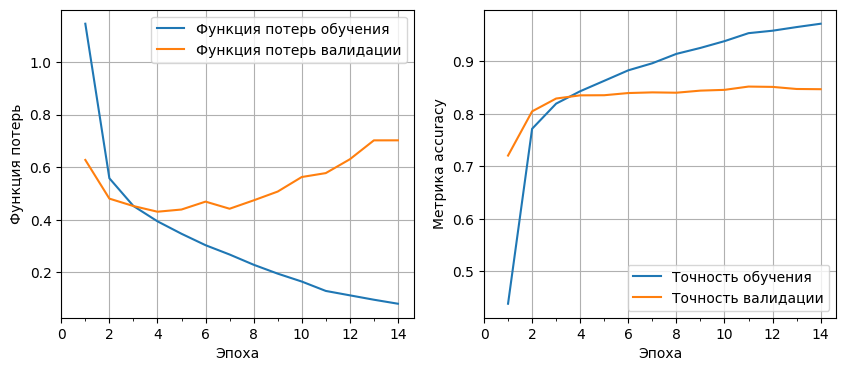

In [193]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
EPOCHS = len(history['loss'])
axs[0].plot(np.arange(1, EPOCHS + 1), history['loss'], label='Функция потерь обучения')
axs[0].plot(np.arange(1, EPOCHS + 1), history['val_loss'], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, EPOCHS + 1, 2))
axs[0].set_xticks(np.arange(0, EPOCHS + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, EPOCHS + 1), history['accuracy'], label='Точность обучения')
axs[1].plot(np.arange(1, EPOCHS + 1), history['val_accuracy'], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, EPOCHS + 1, 2))
axs[1].set_xticks(np.arange(0, EPOCHS + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

In [194]:
test_total_loss, test_correct = 0, 0

model.eval() # переводим модель в режим инференса
with torch.no_grad():
    for writes, labels in dataloader_test:
        writes, labels = writes.to(device), labels.to(device)

        outputs = model(writes)
        loss = criterion(outputs, labels.float())

        test_total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
        test_correct += (predicted == labels.float()).all(1).sum().item()

test_loss = test_total_loss / len(dataloader_test)
test_accuracy = test_correct / len(dataloader_test.dataset)
print('Ошибка:', test_loss)
print('Точность:', test_accuracy)

Ошибка: 0.43075206875801086
Точность: 0.8352842809364549


# Conv RNN

In [195]:
class ConvRNN(nn.Module):
    def __init__(self):
        super(ConvRNN, self).__init__()
        self.embd = nn.Embedding(n_most_common_words, EMBEDDING_DIM)
        self.conv1 = nn.Conv1d(in_channels=EMBEDDING_DIM, out_channels=128, kernel_size=5, padding=2)
        self.drop1 = nn.Dropout(0.2)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, padding=2)
        self.drop2 = nn.Dropout(0.2)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, padding=2)
        self.global_pool = GlobalMaxPool1D()
        self.drop3 = nn.Dropout(0.5)
        self.fc = nn.Linear(128, 8)

    def forward(self, x):
        x = self.embd(x).transpose(1, 2)
        x = self.relu(self.conv1(x))
        x = self.drop1(x)
        x = self.relu(self.conv2(x))
        x = self.drop2(x)
        x = self.relu(self.conv3(x))
        x = self.global_pool(x.transpose(1, 2))
        x = self.drop3(x)
        out = self.fc(x)
        return out

In [196]:
model = ConvRNN()

In [197]:
criterion = nn.CrossEntropyLoss()

In [198]:
LEARNING_RATE_PT = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_PT)

In [199]:
# Функция для проведения одной эпохи обучения
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()   # переводим модель в режим обучения, включая dropout и batchnorm слои
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for writes, labels in progress_bar:  # перебор обучающей выборки на одной эпохе
        writes, labels = writes.to(device), labels.to(device)

        optimizer.zero_grad()   # обнуление градиентов, которые остались с предыдущего шага
        outputs = model(writes) # пропускаем данные батча через модель
        loss = criterion(outputs, labels.float())   # вычисляем функцию потерь
        loss.backward() # обратное распространение ошибки
        optimizer.step()    # делаем шаг оптимизатора

        total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
        correct += (predicted == labels.float()).all(1).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    # Подсчет метрик и функции потерь на тестовой выборке после окончания эпохи
    model.eval() # переводим модель в режим инференса
    with torch.no_grad():
        for writes, labels in test_data_loader:
            writes, labels = writes.to(device), labels.to(device)

            outputs = model(writes)
            loss = criterion(outputs, labels.float())

            test_total_loss += loss.item()
            # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
            predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
            test_correct += (predicted == labels.float()).all(1).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [200]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cuda


ConvRNN(
  (embd): Embedding(1000, 64)
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (drop1): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
  (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (drop2): Dropout(p=0.2, inplace=False)
  (conv3): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (global_pool): GlobalMaxPool1D()
  (drop3): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)

In [201]:
patience = 10

best_val_loss = float("inf")
best_epoch = 0
best_state_dict = None
epochs_no_improve = 0

EPOCHS_PT = 1000
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(EPOCHS_PT):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{EPOCHS_PT}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_epoch = epoch+1
        best_state_dict = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Epoch {epoch+1}: early stopping")
            if best_state_dict is not None:
                model.load_state_dict(best_state_dict)
                print(f"Restoring model weights from the end of the best epoch: {best_epoch}")
            break


Epoch 1/1000, Loss: 1.2448, Accuracy: 0.3740, Test Loss: 0.7415, Test Accuracy: 0.6530



Epoch 2/1000, Loss: 0.6975, Accuracy: 0.6905, Test Loss: 0.5798, Test Accuracy: 0.7500



Epoch 3/1000, Loss: 0.5805, Accuracy: 0.7507, Test Loss: 0.5499, Test Accuracy: 0.7414



Epoch 4/1000, Loss: 0.5131, Accuracy: 0.7837, Test Loss: 0.5093, Test Accuracy: 0.7722



Epoch 5/1000, Loss: 0.4700, Accuracy: 0.8025, Test Loss: 0.5069, Test Accuracy: 0.7855


...


Epoch 12/1000, Loss: 0.3061, Accuracy: 0.8774, Test Loss: 0.5215, Test Accuracy: 0.8135



Epoch 13/1000, Loss: 0.2974, Accuracy: 0.8803, Test Loss: 0.5330, Test Accuracy: 0.8081



Epoch 14/1000, Loss: 0.2786, Accuracy: 0.8892, Test Loss: 0.5450, Test Accuracy: 0.8186



Epoch 15/1000, Loss: 0.2690, Accuracy: 0.8920, Test Loss: 0.5438, Test Accuracy: 0.8156



Epoch 16/1000, Loss: 0.2592, Accuracy: 0.8971, Test Loss: 0.5498, Test Accuracy: 0.8198
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6


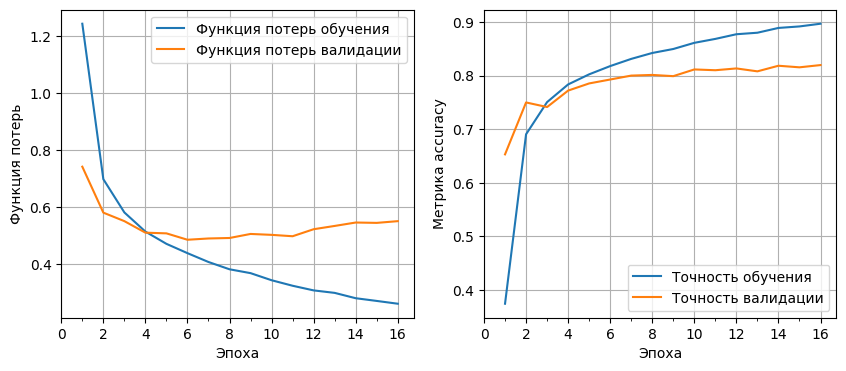

In [202]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
EPOCHS = len(history['loss'])
axs[0].plot(np.arange(1, EPOCHS + 1), history['loss'], label='Функция потерь обучения')
axs[0].plot(np.arange(1, EPOCHS + 1), history['val_loss'], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, EPOCHS + 1, 2))
axs[0].set_xticks(np.arange(0, EPOCHS + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, EPOCHS + 1), history['accuracy'], label='Точность обучения')
axs[1].plot(np.arange(1, EPOCHS + 1), history['val_accuracy'], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, EPOCHS + 1, 2))
axs[1].set_xticks(np.arange(0, EPOCHS + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

In [203]:
test_total_loss, test_correct = 0, 0

model.eval() # переводим модель в режим инференса
with torch.no_grad():
    for writes, labels in dataloader_test:
        writes, labels = writes.to(device), labels.to(device)

        outputs = model(writes)
        loss = criterion(outputs, labels.float())

        test_total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.softmax(outputs, dim=1) > 0.5).float()
        test_correct += (predicted == labels.float()).all(1).sum().item()

test_loss = test_total_loss / len(dataloader_test)
test_accuracy = test_correct / len(dataloader_test.dataset)
print('Ошибка:', test_loss)
print('Точность:', test_accuracy)

Ошибка: 0.48437178919189855
Точность: 0.7928511705685619


# Вывод

Однонаправленная и Двунаправленная LSTM показывают слабое различие в качестве работы. Так как смысл текста слабо зависит от обратного направления

Сверточные сети показывают точность на пару процентов ниже, так как сверточные сети быстро забывают информацию